## Multiplayer Proxy Failure

In [1]:
import pandas as pd
import module_generate_data 


In [ ]:
import pandas as pd
import module_generate_data 

use_baby_params =True

data_file_dump = 'data_test_Uni_2_no_S.csv'
number_of_instances = 100
param_grid = {
    'n': [128, 256, 512, 1024], 
    'trials': [50],
    'proxy_discard': [50],
    'goal_discard': [50, 150, 250, 450],
    'measure_time': [50],
    'alpha': [0.1],
    "avg_number_of_edges": [5,10,20,40], 
    "weight_range": [2]
}


if use_baby_params:
    data_file_dump = 'data_file_dump_baby.csv'
    number_of_instances = 1
    param_grid = {
    'n': [512], 
    'trials': [2],
    'proxy_discard': [50],
    'goal_discard': [50],
    'measure_time': [50],
    'alpha': [0.1],
    "avg_number_of_edges": [1.5], 
    "weight_range": [1]
}
    module_generate_data.generate_experimental_data(data_file_dump, param_grid, number_of_instances, intention = 'w', skip_to = 0, seed_skip=0, nb_cores=3)
else:

    module_generate_data.generate_experimental_data(data_file_dump, param_grid, number_of_instances, intention = 'a', skip_to = 62, seed_skip=0, nb_cores=20)

param_combinations 64
skipping to 62 out of 64
data_test_Uni_2_no_S.csv a
instance 62 out of  64 name ESN_n_1024_goal_discard_450_avg_number_of_edges_10
instance 63 out of  64 name ESN_n_1024_goal_discard_450_avg_number_of_edges_20


KeyboardInterrupt: 

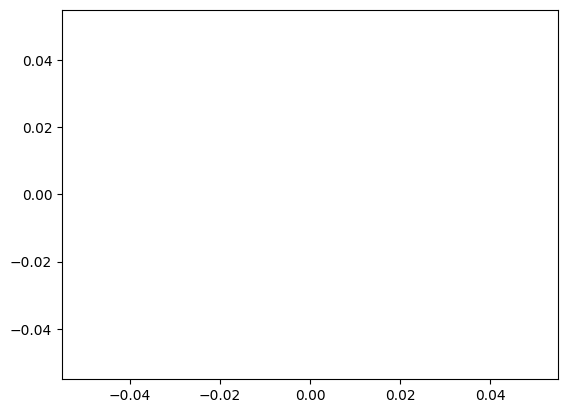

1.9528669864264279 0.9128709291752769


In [2]:
import matplotlib.pyplot as plt
import module_ESN
import random
import math
param_grid = {
    'n': [100], 
    'trials': [5],
    'proxy_discard': [50],
    'goal_discard': [50],
    'measure_time': [50],
    'alpha': [0.1],
    "avg_number_of_edges": [10]
}
def run_one_display():
    a = param_grid
    param_ESN = dict(zip(param_grid.keys(), [param_grid[k][0] for k in param_grid.keys()]))
    esn = module_ESN.EchoStateNetwork(param_ESN['n'],  alpha = param_ESN['alpha'], 
                                avg_number_of_edges=param_ESN['avg_number_of_edges'], proxy_discard=param_ESN['proxy_discard'],
                                goal_discard=param_ESN['goal_discard'], measure_time=param_ESN['measure_time'], seed=random.randint(0,10000)    )
    actions = esn.get_base_action_value(len(esn.action_nodes))
    states = esn.run( agent_values=actions)
    plt.plot(states[:, 180:200], label='goal node')
    plt.show()
    print(esn.spectral_radius, math.sqrt(esn.avg_number_of_edges/12))
run_one_display()


{'n': 128, 'trials': 50, 'proxy_discard': 50, 'goal_discard': 50, 'measure_time': 50, 'alpha': 0.1, 'avg_number_of_edges': 5, 'weight_range': 2}


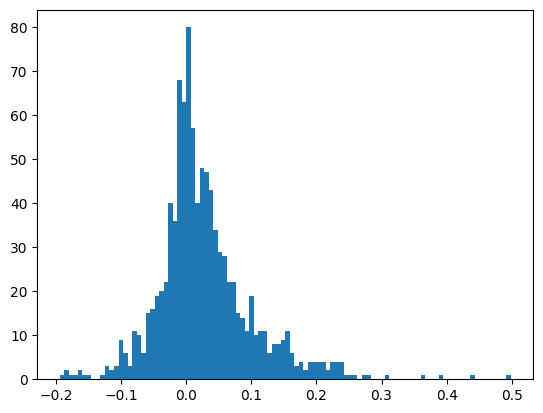

In [12]:
import matplotlib.pyplot as plt

number_of_instances = 100
param_grid = {
    'n': [128, 256, 512, 1024], 
    'trials': [50],
    'proxy_discard': [50],
    'goal_discard': [50, 150, 250, 450],
    'measure_time': [50],
    'alpha': [0.1],
    "avg_number_of_edges": [5,10,20,40], 
    "weight_range": [2]
}


repeats = 1000
Losses = []
for k in range(1):
    param_sub_grid = param_grid.copy()
    param_sub_grid['n'] = [param_grid['n'][k]]
    param_sub_grid['avg_number_of_edges'] = [param_grid['avg_number_of_edges'][k]]
    param_sub_grid['goal_discard'] = [param_grid['goal_discard'][k]]
    param_sub_grid = {k: param_sub_grid[k][0] for k in param_sub_grid.keys()}
    print(param_sub_grid)
    for i in range(repeats):
        a = module_generate_data.parallel_compute_mean_regression(param_sub_grid, seed = i)
        Losses.append(a['loss_corr'])
    plt.hist(Losses, bins=100)

In [13]:
import numpy as np
print(np.mean(Losses),sum([1 for k in Losses if k > 0])/len(Losses))

0.02779403968917056 0.635
